In [61]:
!pip install --upgrade tensorflow
!pip install --upgrade keras
!pip install opencv-python


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import matplotlib.pyplot as plt
import numpy as np
import math
import cv2

## Import the keras API
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Input, Reshape, MaxPooling2D, Conv2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam

#Cargar datos de ejemplo
import tensorflow as tf

In [63]:
normalizer = 255
def cargar_datos(fase, numeroCategorias, limite):
    imagenesCargadas=[]
    etiquetas=[]
    valorEsperado=[]
    for categoria in range(0,numeroCategorias):
        for idImagen in range(1,limite):
            ruta=f'{fase}/{categoria}/{categoria}_{idImagen}.jpg'
            # fase+str(categoria)+"/"+str(categoria)+"_"+str(idImagen)+".jpg"
            print(f'{ruta=}')
            imagen=cv2.imread(ruta,0)
            imagen=imagen.flatten()
            imagen=imagen/normalizer
            imagenesCargadas.append(imagen)
            etiquetas.append(categoria)
            probabilidades=np.zeros(numeroCategorias)
            probabilidades[categoria]=1
            valorEsperado.append(probabilidades)
    imagenesEntrenamiento=np.array(imagenesCargadas)
    etiquetasEntrenamiento=np.array(etiquetas)
    valoresEsperados=np.array(valorEsperado)
    return imagenesEntrenamiento, etiquetasEntrenamiento, valoresEsperados

In [64]:
# from google.colab import drive
# drive.mount("/content/drive")

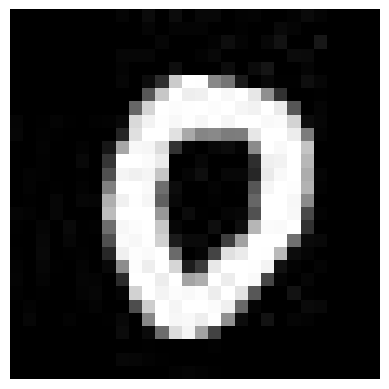

In [65]:
import cv2
from matplotlib import pyplot as plt

path = './cnnimg/dataset/0/0_1.jpg'

imagen=cv2.imread(path,0)

if imagen is None:
  print("error al cargar la imagen")
else:
  plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()


In [66]:
img_size=28
#Numero de neuronas de la cnn
img_size_flat=img_size*img_size
#Parametrizar la forma de imagenes
num_chanels=1
#RGB, HSV -> num_chanels=3
img_shape=(img_size,img_size,num_chanels)
num_clases=10
limiteImagenesPrueba=60
imagenes,etiquetas,probabilidades = cargar_datos(
    './cnnimg/dataset/',
    num_clases,
    limiteImagenesPrueba
)

ruta='./cnnimg/dataset//0/0_1.jpg'
ruta='./cnnimg/dataset//0/0_2.jpg'
ruta='./cnnimg/dataset//0/0_3.jpg'
ruta='./cnnimg/dataset//0/0_4.jpg'
ruta='./cnnimg/dataset//0/0_5.jpg'
ruta='./cnnimg/dataset//0/0_6.jpg'
ruta='./cnnimg/dataset//0/0_7.jpg'
ruta='./cnnimg/dataset//0/0_8.jpg'
ruta='./cnnimg/dataset//0/0_9.jpg'
ruta='./cnnimg/dataset//0/0_10.jpg'
ruta='./cnnimg/dataset//0/0_11.jpg'
ruta='./cnnimg/dataset//0/0_12.jpg'
ruta='./cnnimg/dataset//0/0_13.jpg'
ruta='./cnnimg/dataset//0/0_14.jpg'
ruta='./cnnimg/dataset//0/0_15.jpg'
ruta='./cnnimg/dataset//0/0_16.jpg'
ruta='./cnnimg/dataset//0/0_17.jpg'
ruta='./cnnimg/dataset//0/0_18.jpg'
ruta='./cnnimg/dataset//0/0_19.jpg'
ruta='./cnnimg/dataset//0/0_20.jpg'
ruta='./cnnimg/dataset//0/0_21.jpg'
ruta='./cnnimg/dataset//0/0_22.jpg'
ruta='./cnnimg/dataset//0/0_23.jpg'
ruta='./cnnimg/dataset//0/0_24.jpg'
ruta='./cnnimg/dataset//0/0_25.jpg'
ruta='./cnnimg/dataset//0/0_26.jpg'
ruta='./cnnimg/dataset//0/0_27.jpg'
ruta='./cnnimg/dataset//0/0_28.jpg'
r

In [ ]:
model=Sequential()
#Capa entrada
model.add(InputLayer(input_shape=(img_size_flat,)))
#Reformar imagen
model.add(Reshape(img_shape))

#Capas convolucionales
model.add(Conv2D(
    kernel_size=5,
    strides=1,
    filters=16,
    padding='same',
    activation='relu',
    name='capa_convolucion_1'
))
model.add(MaxPooling2D(pool_size=2,strides=2))

model.add(Conv2D(
    kernel_size=5,
    strides=1,
    filters=36,
    padding='same',
    activation='relu',
    name='capa_convolucion_2'
))
model.add(MaxPooling2D(pool_size=2,strides=2))

#Aplanar imagen
model.add(Flatten())
#Capa densa
model.add(Dense(128,activation='relu'))
#Capa salida
model.add(Dense(num_clases,activation='softmax'))



c:\Users\overd\Links\Academia\Inteligent\Systems\Classroom\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [68]:
#Compilacion del modelo
optimizador=Adam()
model.compile(optimizer='Adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

In [69]:
print(model.summary())
model.fit(x=imagenes,y=probabilidades,epochs=30,batch_size=60)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_convolucion_1 (Conv2D)     │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_convolucion_2 (Conv2D)     │ (None, 14, 14, 36)     │        14,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1764)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       225,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,062 (945.55 KB)

 Trainable params: 242,062 (945.55 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2578 - loss: 2.1761
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7059 - loss: 1.3163
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7807 - loss: 0.7329
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8147 - loss: 0.5606
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8741 - loss: 0.4119
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9063 - loss: 0.3326
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9289 - loss: 0.2333
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9343 - loss: 0.2227
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9519 - loss: 0.1649
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9592 - loss: 0.1280
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9717 - loss: 0.0940
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accu

In [70]:
#Entrenamiento del modelo
#model.fit(x=imagenes,y=probabilidades,epochs=10,batch_size=100)

limiteImagenesPrueba=20
imagenes_prueba, etiquetas_prueba, probabilidades_prueba =\
    cargar_datos('./cnnimg/test/',num_clases,limiteImagenesPrueba)
resultados=model.evaluate(x=imagenes_prueba,y=probabilidades_prueba)
print("{0}: {1:.2%}".format(model.metrics_names[1], resultados[1]))
#Carpeta y nombre del archivo como se almacenará el modelo
nombreArchivo = './cnnimg/models/modeloReconocimientoNumeros.h5'
model.save(nombreArchivo)
model.summary()

ruta='./cnnimg/test//0/0_1.jpg'
ruta='./cnnimg/test//0/0_2.jpg'
ruta='./cnnimg/test//0/0_3.jpg'
ruta='./cnnimg/test//0/0_4.jpg'
ruta='./cnnimg/test//0/0_5.jpg'
ruta='./cnnimg/test//0/0_6.jpg'
ruta='./cnnimg/test//0/0_7.jpg'
ruta='./cnnimg/test//0/0_8.jpg'
ruta='./cnnimg/test//0/0_9.jpg'
ruta='./cnnimg/test//0/0_10.jpg'
ruta='./cnnimg/test//0/0_11.jpg'
ruta='./cnnimg/test//0/0_12.jpg'
ruta='./cnnimg/test//0/0_13.jpg'
ruta='./cnnimg/test//0/0_14.jpg'
ruta='./cnnimg/test//0/0_15.jpg'
ruta='./cnnimg/test//0/0_16.jpg'
ruta='./cnnimg/test//0/0_17.jpg'
ruta='./cnnimg/test//0/0_18.jpg'
ruta='./cnnimg/test//0/0_19.jpg'
ruta='./cnnimg/test//1/1_1.jpg'
ruta='./cnnimg/test//1/1_2.jpg'
ruta='./cnnimg/test//1/1_3.jpg'
ruta='./cnnimg/test//1/1_4.jpg'
ruta='./cnnimg/test//1/1_5.jpg'
ruta='./cnnimg/test//1/1_6.jpg'
ruta='./cnnimg/test//1/1_7.jpg'
ruta='./cnnimg/test//1/1_8.jpg'
ruta='./cnnimg/test//1/1_9.jpg'
ruta='./cnnimg/test//1/1_10.jpg'
ruta='./cnnimg/test//1/1_11.jpg'
ruta='./cnnimg/test//1/1_12.

compile_metrics: 100.00%


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_2 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_convolucion_1 (Conv2D)     │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_convolucion_2 (Conv2D)     │ (None, 14, 14, 36)     │        14,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1764)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       225,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 726,188 (2.77 MB)

 Trainable params: 242,062 (945.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 484,126 (1.85 MB)

In [71]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2

class prediccion():
    """
    Carga el modelo de la red neuronal de la ruta especificada
    """
    def __init__(self):
        self.rutaModelo="./cnnimg/models/modeloReconocimientoNumeros.h5"
        self.model=load_model(self.rutaModelo)
        self.width=28
        self.heigth=28

    def predecir(self,imagen):
        """
            Toma la imagen de entrada y realiza el proceso de predicción
        """
        imagen=cv2.resize(imagen,(self.width,self.heigth))
        imagen=imagen.flatten()
        imagen=np.array(imagen)
        imagenNormalizada=imagen/255
        pruebas=[]
        pruebas.append(imagenNormalizada)
        imagenesAPredecir=np.array(pruebas)
        predicciones=self.model.predict(x=imagenesAPredecir)
        claseMayorValor=np.argmax(predicciones,axis=1)
        print(predicciones)
        print (claseMayorValor)
        return claseMayorValor[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[1.9486276e-08 4.9851583e-13 1.5671759e-16 8.6939190e-06 2.2129878e-08
  9.9998069e-01 3.1377619e-13 4.0442441e-08 2.1332428e-06 8.4707499e-06]]
[5]
La imagen cargada es  5


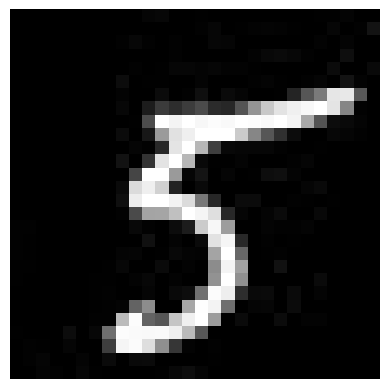

In [72]:

categorias=["0","1","2","3","4","5","6","7","8","9"]
reconocimiento=prediccion()
imagenPrueba=cv2.imread("./cnnimg/test/5/5_11.jpg",0)
indiceCategoria=reconocimiento.predecir(imagenPrueba)
print("La imagen cargada es ",categorias[indiceCategoria])

imagen=cv2.imread("./cnnimg/test/5/5_11.jpg",0)

if imagen is None:
  print("error al cargar la imagen")
else:
  plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()